In [1]:
import numpy as np
import pandas as pd
import sklearn.linear_model as skl_lm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV



# To get nicer plots
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100   # optional: adjust resolution
%config InlineBackend.figure_format = 'svg'  # Jupyter magic for SVG output
from IPython.core.pylabtools import figsize
figsize(10, 6) # Width and hight
np.set_printoptions(precision=3);

In [2]:
# Load library

training_data = pd.read_csv("training_data.csv")

training_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hour_of_day     1600 non-null   int64  
 1   day_of_week     1600 non-null   int64  
 2   month           1600 non-null   int64  
 3   holiday         1600 non-null   int64  
 4   weekday         1600 non-null   int64  
 5   summertime      1600 non-null   int64  
 6   temp            1600 non-null   float64
 7   dew             1600 non-null   float64
 8   humidity        1600 non-null   float64
 9   precip          1600 non-null   float64
 10  snow            1600 non-null   int64  
 11  snowdepth       1600 non-null   float64
 12  windspeed       1600 non-null   float64
 13  cloudcover      1600 non-null   float64
 14  visibility      1600 non-null   float64
 15  increase_stock  1600 non-null   object 
dtypes: float64(8), int64(7), object(1)
memory usage: 200.1+ KB


In [3]:
training_data.head()


,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility,increase_stock
0,5,5,1,0,0,0,-7.2,-15.0,53.68,0.0,0,0.0,16.3,31.6,16.0,low_bike_demand
1,21,4,1,0,1,0,-1.3,-12.8,40.97,0.0,0,0.0,23.9,85.7,16.0,low_bike_demand
2,21,3,8,0,1,1,26.9,21.8,73.39,0.0,0,0.0,0.0,81.1,16.0,low_bike_demand
3,1,6,1,0,0,0,3.1,-4.0,59.74,0.0,0,0.0,19.2,0.0,16.0,low_bike_demand
4,17,0,3,0,1,0,11.7,-11.4,18.71,0.0,0,0.0,10.5,44.6,16.0,low_bike_demand


In [4]:
training_data.describe()


,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility
count,1600.00000,1600.000000,1600.000000,1600.000000,1600.000000,1600.00000,1600.000000,1600.000000,1600.000000,1600.000000,1600.0,1600.000000,1600.000000,1600.000000,1600.000000
mean,11.37125,3.022500,6.468750,0.033125,0.710000,0.64375,15.210313,7.750750,63.927844,0.122042,0.0,0.042713,13.082500,64.322375,15.344125
std,6.94837,2.012965,3.454741,0.179019,0.453904,0.47904,9.264785,10.026459,19.079419,0.920600,0.0,0.421198,7.756652,32.748869,2.323737
min,0.00000,0.000000,1.000000,0.000000,0.000000,0.00000,-9.100000,-18.400000,15.850000,0.000000,0.0,0.000000,0.000000,0.000000,0.100000
25%,5.00000,1.000000,3.000000,0.000000,0.000000,0.00000,7.700000,-0.800000,47.845000,0.000000,0.0,0.000000,7.500000,28.800000,16.000000
50%,12.00000,3.000000,6.000000,0.000000,1.000000,1.00000,15.500000,8.300000,65.175000,0.000000,0.0,0.000000,12.300000,79.300000,16.000000
75%,17.00000,5.000000,9.000000,0.000000,1.000000,1.00000,23.200000,16.800000,79.955000,0.000000,0.0,0.000000,17.600000,92.800000,16.000000
max,23.00000,6.000000,12.000000,1.000000,1.000000,1.00000,35.600000,24.300000,99.890000,25.871000,0.0,6.710000,43.800000,100.000000,16.000000


In [5]:
training_data['High_demand'] = (training_data['increase_stock'] == 'high_bike_demand').astype(int)


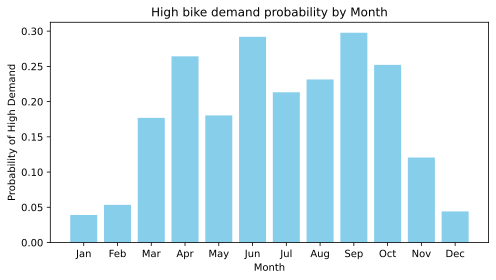

In [6]:
# Probability of high demand by month
prob_high_month = training_data.groupby('month')['High_demand'].mean()

plt.figure(figsize=(7,4))
plt.bar(prob_high_month.index, prob_high_month.values, color='skyblue')
plt.xticks(prob_high_month.index,
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month')
plt.ylabel('Probability of High Demand')
plt.title('High bike demand probability by Month')

plt.tight_layout()  # ensures labels are inside the figure

# Save the figure BEFORE showing it
plt.savefig('high_demand_by_month.png', dpi=300)

plt.show()

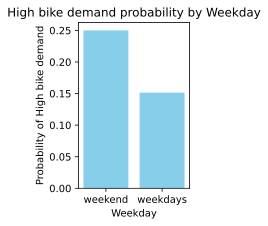

In [7]:
# Probability of high demand by weekday
prob_high_weekday = training_data.groupby('weekday')['High_demand'].mean()
plt.figure(figsize=(2,3))
plt.bar(prob_high_weekday.index, prob_high_weekday.values, color='skyblue')
plt.xticks(prob_high_weekday.index, ['weekend', 'weekdays'])
plt.xlabel('Weekday')
plt.ylabel('Probability of High bike demand')
plt.title('High bike demand probability by Weekday')

plt.savefig("High_demand_by_weekday.png", bbox_inches='tight')
plt.show()

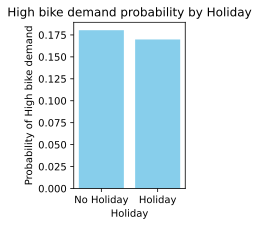

In [8]:
# Probability of high demand by holiday
prob_high_holiday = training_data.groupby('holiday')['High_demand'].mean()
plt.figure(figsize=(2,3))
plt.bar(prob_high_holiday.index, prob_high_holiday.values, color='skyblue')
plt.xticks(prob_high_holiday.index, ['No Holiday', 'Holiday'])
plt.xlabel('Holiday')
plt.ylabel('Probability of High bike demand')
plt.title('High bike demand probability by Holiday')

plt.savefig("High_demand_by_holiday.png", bbox_inches='tight')
plt.show()

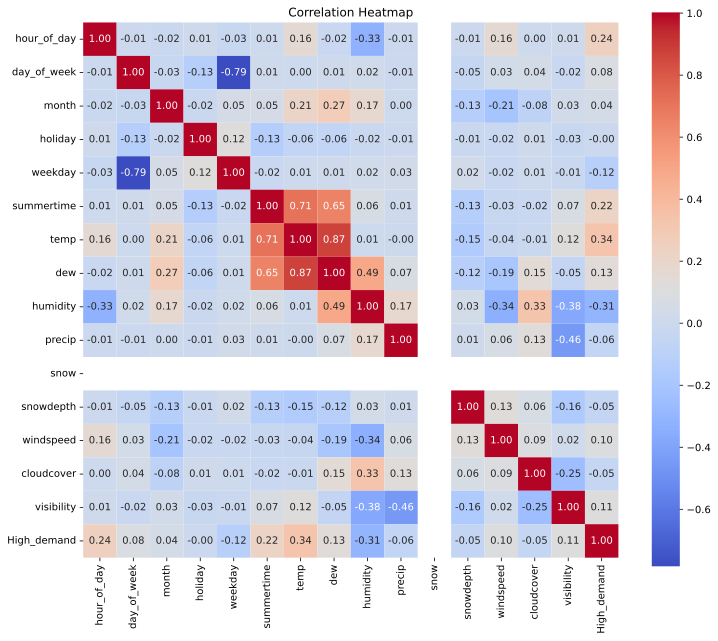

In [9]:
# Correlation heatmap
training_data['high_numeric'] = training_data['High_demand'].astype(int)
training_data['high_numeric'] = 'high_numeric'

numeric_cols = training_data.select_dtypes(include='number')

corr = numeric_cols.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", bbox_inches='tight')  # saves with proper layout
plt.show()



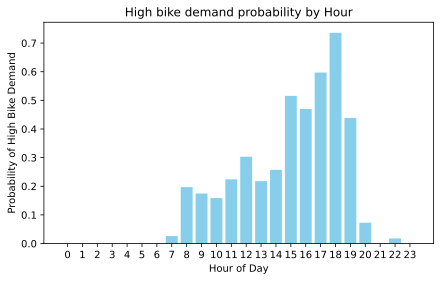

In [10]:
# Compute probability of high demand per hour
hour_prob = training_data.groupby('hour_of_day')['High_demand'].mean()

# Plot
plt.figure(figsize=(7,4))
plt.bar(hour_prob.index, hour_prob.values, color='skyblue')
plt.xlabel('Hour of Day')
plt.ylabel('Probability of High Bike Demand')
plt.title('High bike demand probability by Hour')
plt.xticks(range(0,24))

plt.savefig("High_demand_by_hour.png", bbox_inches='tight')  # saves with proper layout
plt.show()

C:\Users\lober\AppData\Local\Temp\ipykernel_18088\4284271439.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_prob = training_data.groupby('temp_bin')['High_demand'].mean()


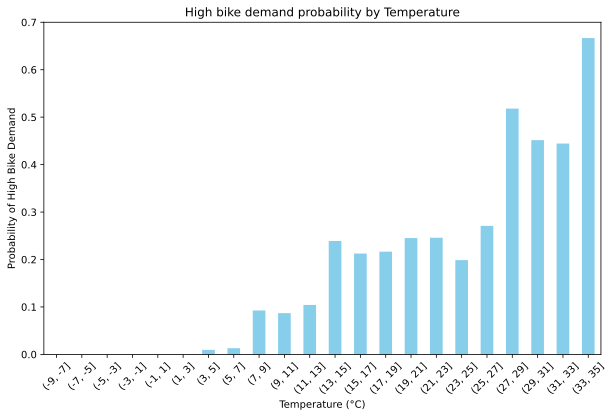

In [11]:
# Bin temperature into intervals
temp_bins = np.arange(int(training_data['temp'].min()), int(training_data['temp'].max())+2, 2)  # e.g., bins of size 2°C
training_data['temp_bin'] = pd.cut(training_data['temp'], bins=temp_bins)

# Compute probability of high demand per temperature bin
temp_prob = training_data.groupby('temp_bin')['High_demand'].mean()

# Plot
plt.figure(figsize=(10,6))
temp_prob.plot(kind='bar', color='skyblue')
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability of High Bike Demand')
plt.title('High bike demand probability by Temperature')
plt.xticks(rotation=45)
plt.savefig("High_demand_by_temperature.png", bbox_inches='tight')  # saves with proper layout
plt.show()


<Figure size 1000x600 with 0 Axes>

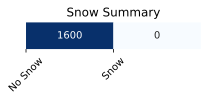

In [13]:


# Summarize snow
snow_summary = training_data['snow'].value_counts().reindex([0, 1], fill_value=0)
snow_summary.index = ['No Snow', 'Snow']
snow_summary_df = pd.DataFrame({'Snow status': snow_summary.index, 'Count': snow_summary.values})
# Save the figure as a PNG
plt.savefig("snow_summary.png", dpi=300)
plt.show()

# Plot as a heatmap
plt.figure(figsize=(3, 1.5))
sns.heatmap(snow_summary_df[['Count']].T, annot=True, fmt="d", cbar=False, cmap="Blues")
plt.yticks([], rotation=0)
plt.xticks(ticks=[0, 1], labels=snow_summary_df['Snow status'], rotation=45)
plt.title("Snow Summary")
plt.tight_layout()